# Checking out the (possibly) most promising dataset

... though that _possibly_ is yet to be confirmed:
- there are no road annotations
- would need to crop large tiles and curate appropriately
- and found some irregularities in the data..?

Still, it has uniform ground resolution, a lot of images, and bounding boxes which make sampling (and transforms) relatively easy.


In [1]:
# re-loads code before cell execution, so if sth changes it will propagate:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys

import time as tm
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image

sys.path.append('..')

import src.plotting as splo
import src.data_utils as sdut
import src.geom_utils as sgut

## Set up namespace, e.g. point to data

In [3]:
data_path = '../data/xView-train_images-subset/'
label_file = '../../xView_train.geojson'

In [4]:
labelnames_di = {
    11:'Fixed-wing Aircraft', 12:'Small Aircraft', 13:'Passenger/Cargo Plane', 15:'Helicopter',
    17:'Passenger Vehicle', 18:'Small Car', 19:'Bus', 20:'Pickup Truck', 21:'Utility Truck',
    23:'Truck', 24:'Cargo Truck', 25:'Truck Tractor w/ Box Trailer', 26:'Truck Tractor',27:'Trailer',
    28:'Truck Tractor w/ Flatbed Trailer', 29:'Truck Tractor w/ Liquid Tank', 32:'Crane Truck',
    33:'Railway Vehicle', 34:'Passenger Car', 35:'Cargo/Container Car', 36:'Flat Car', 37:'Tank car',
    38:'Locomotive', 40:'Maritime Vessel', 41:'Motorboat', 42:'Sailboat', 44:'Tugboat', 45:'Barge',
    47:'Fishing Vessel', 49:'Ferry', 50:'Yacht', 51:'Container Ship', 52:'Oil Tanker',
    53:'Engineering Vehicle', 54:'Tower crane', 55:'Container Crane', 56:'Reach Stacker',
    57:'Straddle Carrier', 59:'Mobile Crane', 60:'Dump Truck', 61:'Haul Truck', 62:'Scraper/Tractor',
    63:'Front loader/Bulldozer', 64:'Excavator', 65:'Cement Mixer', 66:'Ground Grader', 71:'Hut/Tent',
    72:'Shed', 73:'Building', 74:'Aircraft Hangar', 76:'Damaged Building', 77:'Facility', 79:'Construction Site',
    83:'Vehicle Lot', 84:'Helipad', 86:'Storage Tank', 89:'Shipping container lot', 91:'Shipping Container',
    93:'Pylon', 94:'Tower'}

## Inital check-out of the data structure


In [5]:
label_di = sdut.from_json( label_file)
for k,v in label_di.items():
    print(k,type(v))

crs <class 'dict'>
type <class 'str'>
features <class 'list'>
name <class 'str'>


In [6]:
label_di['crs'], label_di['type'], label_di['name'], len(label_di['features'])

({'properties': {'name': 'urn:ogc:def:crs:OGC:1.3:CRS84'}, 'type': 'name'},
 'FeatureCollection',
 'U-LIMDIS_xView_Final',
 601937)

In [7]:
label_li = label_di['features']
label_li[0]

{'type': 'Feature',
 'properties': {'bounds_imcoords': '2712,1145,2746,1177',
  'edited_by': 'wwoscarbecerril',
  'cat_id': '1040010028371A00',
  'type_id': 73,
  'ingest_time': '2017/07/24 12:49:09.118+00',
  'index_right': 2356,
  'image_id': '2355.tif',
  'point_geom': '0101000020E6100000616E4E6406A256C03BE6ADA0D6212D40',
  'feature_id': 374410,
  'grid_file': 'Grid2.shp'},
 'geometry': {'type': 'Polygon',
  'coordinates': [[[-90.53169885094464, 14.56603647302396],
    [-90.53169885094464, 14.56614473506768],
    [-90.53158140073565, 14.56614473506768],
    [-90.53158140073565, 14.56603647302396],
    [-90.53169885094464, 14.56603647302396]]]}}

In [8]:
df = pd.DataFrame([x['properties'] for x in label_li])
df.drop(
    labels= ['edited_by','cat_id','point_geom','grid_file','ingest_time'], axis= 1, inplace= True
)
df['cat'] = df['type_id'].map( labelnames_di)
df['bbox'] = df['bounds_imcoords'].map( lambda x: [int(y) for y in x.split(',')])

In [9]:
df.head(3)

,bounds_imcoords,type_id,index_right,image_id,feature_id,cat,bbox
0,"2712,1145,2746,1177",73,2356,2355.tif,374410,Building,"[2712, 1145, 2746, 1177]"
1,"2720,2233,2760,2288",73,2356,2355.tif,394393,Building,"[2720, 2233, 2760, 2288]"
2,"2687,1338,2740,1399",73,2356,2355.tif,374031,Building,"[2687, 1338, 2740, 1399]"


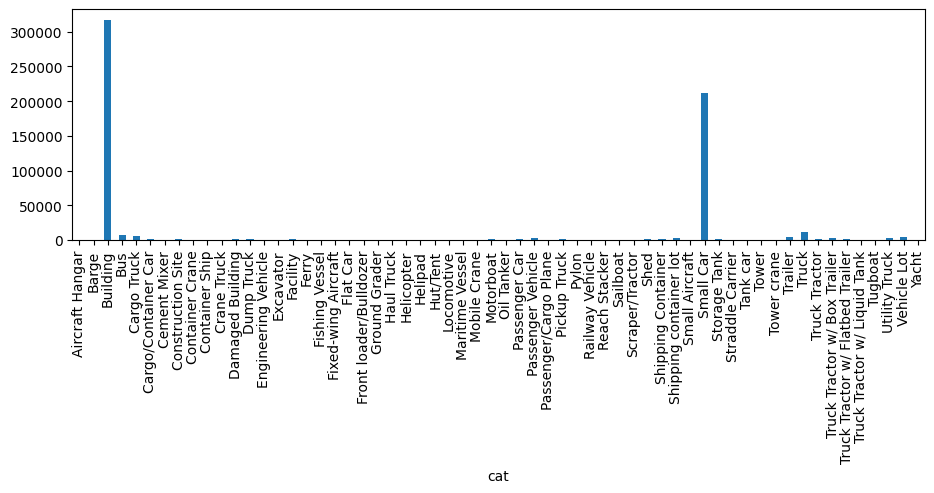

In [10]:
plt.subplots( figsize= (11,3))
_ = df.groupby('cat').count()['type_id'].plot(kind='bar')

In [11]:
dfg = df.groupby('image_id').agg(
    {
        'type_id': [ 
            len, lambda x: len(set(x)), 
            lambda x: len([y for y in x if y == 18]),
            lambda x: len([y for y in x if y == 73])
        ]
    }
).droplevel(level=0,axis=1).rename( 
    columns= {'<lambda_0>': 'n_cats', 'len': 'n_labels', '<lambda_1>':'n_cars', '<lambda_2>':'n_buildings'}
)

In [ ]:
for item in dfg.index:
    try:
        image_ = sduti.to_numpy( sduti.load_image( f'{data_path}{item}'))
        dfg.loc[ item, ['dims','mean','var']] = str(image_.shape), image_.mean(), image_.var()
    except FileNotFoundError:
        print( f'{item} is missing...')

In [13]:
dfg.head(3)

,n_labels,n_cats,n_cars,n_buildings
image_id,,,,
10.tif,63,7,2,44
100.tif,135,3,62,66
102.tif,1965,9,345,1563


<BarContainer object of 847 artists>

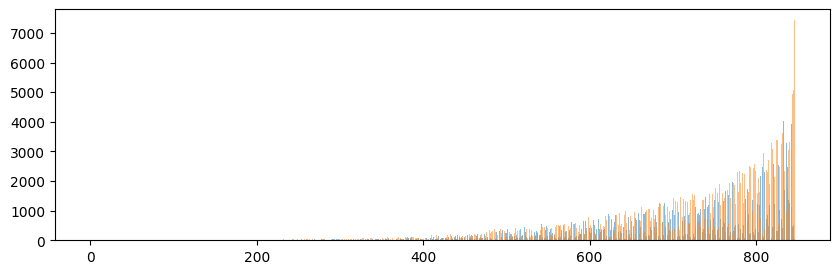

In [12]:
plt.subplots( figsize= (10,3))
#plt.bar(range(len(dfg)),dfg.sort_values(by='n_labels')['n_labels'], alpha= 0.5)
plt.bar(range(len(dfg)),dfg.sort_values(by='n_labels')['n_cars'], alpha= 0.5)
plt.bar(range(len(dfg)),dfg.sort_values(by='n_labels')['n_buildings'], alpha= 0.5)

In [13]:
target_ims = dfg.loc[ dfg['n_cars']>=300].index.tolist()
target_ims = [x for x in target_ims if os.path.exists(f'{data_path}{x}')]
print(f'{len(target_ims)} images')

180 images


In [14]:
sample_im_name = target_ims[0]
df_ = df.loc[ df['image_id']== sample_im_name]
image_ = sdut.to_numpy( sdut.load_image( f'{data_path}{sample_im_name}'))
xmax, ymax, _ = image_.shape
figsize = ( int(xmax / 200), int( ymax/ 200))
sample_im_name

'102.tif'

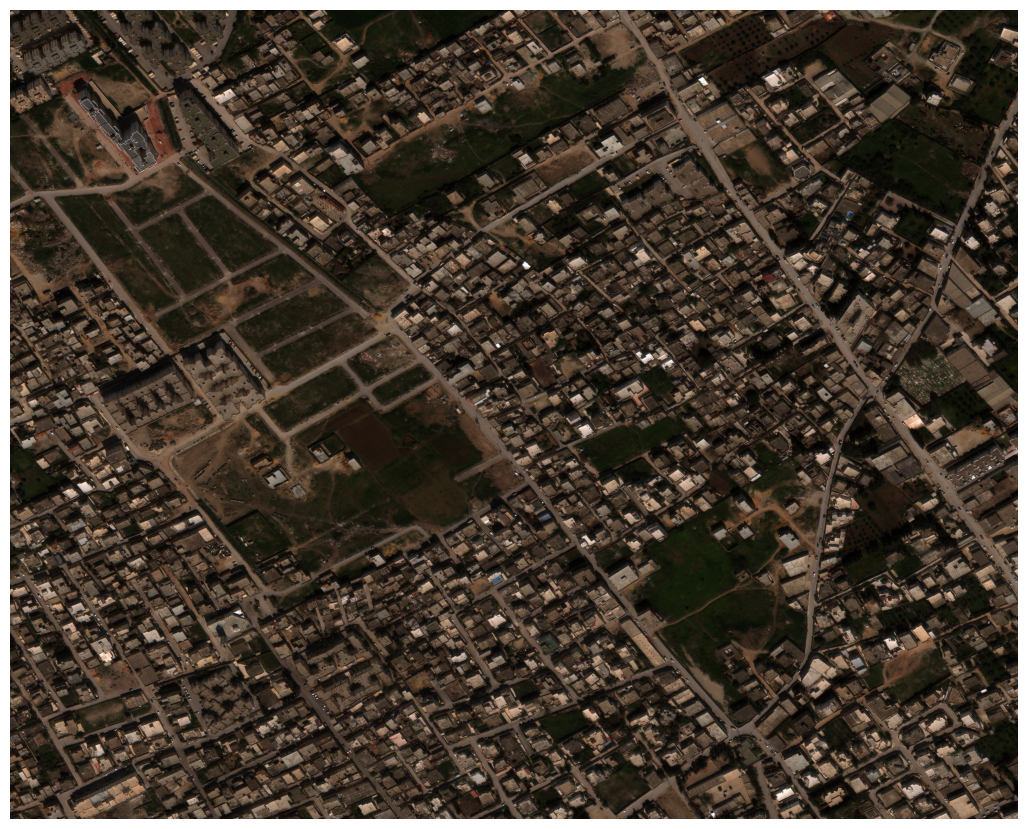

In [15]:
ax = splo.plot_single(image_, figsize= figsize)

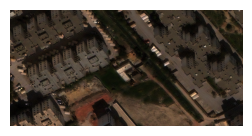

In [16]:
ax = splo.plot_single(image_[0:300,:,:][:,0:600,:], figsize= (3,6))

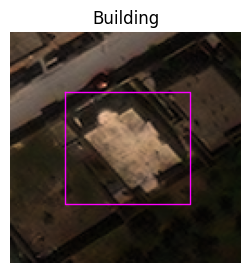

In [23]:
which = 623
bbox_np = sgut.bbox_np(df_.iloc[ which]['bbox'])
category = df_.iloc[ which]['cat']
image_bbox_np, bbox_inner_np = sgut.center_on_bbox( bbox_np, 128, xmax, ymax)
if image_bbox is not None:
    ax = splo.plot_single( sgut.crop_to_bbox( image_, image_bbox_np), figsize= (3,3))
    splo.plot_bbox( *sgut.bbox_np( bbox_inner_np), ax= ax)
    ax.set_title( category)

In [24]:
sample_im_name = '2355.tif'
df_ = df.loc[ df['image_id']== sample_im_name]
image_ = sdut.to_numpy( sdut.load_image( f'{data_path}{sample_im_name}'))
xmax, ymax, _ = image_.shape
figsize = ( int(xmax / 200), int( ymax/ 200))
sample_im_name

'2355.tif'

In [29]:
df_.cat.unique()

array(['Building', 'Small Car', 'Vehicle Lot', 'Utility Truck',
       'Facility', 'Bus', 'Pickup Truck', 'Truck Tractor w/ Box Trailer',
       'Cargo Truck', 'Truck Tractor', 'Trailer', 'Dump Truck',
       'Small Aircraft', 'Excavator', 'Truck Tractor w/ Flatbed Trailer',
       'Shipping container lot'], dtype=object)

<Axes: >

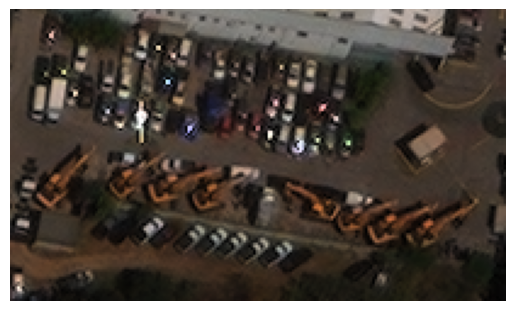

In [28]:
bbox_np = sgut.bbox_np( df_.loc[ df_['cat'] == 'Vehicle Lot'].iloc[1]['bbox'])
splo.plot_single( sgut.crop_to_bbox( image_, bbox_np))